<a href="https://colab.research.google.com/github/useroo5/MachineLearning/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Класифікація зображень CIFAR-10 за допомогою CNN

CNN (Convolutional Neural Network) — згорткова нейронна мережа. Вона автоматично виділяє ознаки (features) із зображення та навчається класифікувати їх.

#1. Імпортуємо необхідні бібліотеки
*Ці бібліотеки вже попередньо встановлені в Google Colab*

In [1]:
# TensorFlow — бібліотека для машинного навчання
import tensorflow as tf
# Keras — високорівнева API для створення нейронних мереж
# layers — модуль із типами шарів нейромереж (наприклад, Conv2D, MaxPooling2D тощо)
# models — модуль для створення моделі
from tensorflow.keras import layers, models
# Matplotlib — для побудови графіків
import matplotlib.pyplot as plt
# NumPy — робота з масивами
import numpy as np
# OpenCV (cv2) — бібліотека для обробки зображень
import cv2
# PIL — для роботи із зображеннями
from PIL import Image

#2. Завантаження та підготовка набору CIFAR-10

CIFAR-10 — набір зображень розміром 32x32 пікселі в 10 класах

['літак', 'автомобіль', 'птах', 'кіт', 'олень', 'собака', 'жаба', 'кінь', 'корабель', 'вантажівка']

In [2]:
# Завантаження CIFAR-10 (32x32 зображення у 10 класах)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [3]:
print(X_test)
print(y_test)

[[[[158 112  49]
   [159 111  47]
   [165 116  51]
   ...
   [137  95  36]
   [126  91  36]
   [116  85  33]]

  [[152 112  51]
   [151 110  40]
   [159 114  45]
   ...
   [136  95  31]
   [125  91  32]
   [119  88  34]]

  [[151 110  47]
   [151 109  33]
   [158 111  36]
   ...
   [139  98  34]
   [130  95  34]
   [120  89  33]]

  ...

  [[ 68 124 177]
   [ 42 100 148]
   [ 31  88 137]
   ...
   [ 38  97 146]
   [ 13  64 108]
   [ 40  85 127]]

  [[ 61 116 168]
   [ 49 102 148]
   [ 35  85 132]
   ...
   [ 26  82 130]
   [ 29  82 126]
   [ 20  64 107]]

  [[ 54 107 160]
   [ 56 105 149]
   [ 45  89 132]
   ...
   [ 24  77 124]
   [ 34  84 129]
   [ 21  67 110]]]


 [[[235 235 235]
   [231 231 231]
   [232 232 232]
   ...
   [233 233 233]
   [233 233 233]
   [232 232 232]]

  [[238 238 238]
   [235 235 235]
   [235 235 235]
   ...
   [236 236 236]
   [236 236 236]
   [235 235 235]]

  [[237 237 237]
   [234 234 234]
   [234 234 234]
   ...
   [235 235 235]
   [235 235 235]
   [234 234

In [4]:
# Нормалізація — перетворення значень пікселів у діапазон [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
# Список назв класів українською мовою
class_name = ['літак', 'автомобіль', 'птах', 'кіт', 'олень', 'собака', 'жаба', 'кінь', 'корабель', 'вантажівка']

#3. Побудова моделі CNN

CNN (Convolutional Neural Network) — згорткова нейронна мережа, що добре працює з зображеннями

- Conv2D: згортковий шар, що виявляє особливості (features)
- MaxPooling2D: зменшує розмірність, зберігаючи важливі ознаки
- Flatten: вирівнює багатовимірні дані у вектор
- Dense: повнозв'язний шар

CNN (Convolutional Neural Network) — працює як ієрархія ознак:
- перші шари шукають прості шаблони (краї, кольорові переходи),
- середні — формують структури (кут, текстура),
- глибші — бачать складні форми (вухо кота, крило літака тощо).

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),  # перший згортковий шар

    # 32 фільтри (або ядра згортки) розміром 3x3
    # relu (Rectified Linear Unit) — нелінійна функція активації: f(x) = max(0, x)
    # input_shape=(32, 32, 3) — 32x32 пікселі, 3 кольорові канали (RGB)

    layers.MaxPooling2D((2,2)),  # 32x32 -> 16x16  # підвибірка (pooling), зменшення розміру у 2 рази

    layers.Conv2D(64, (3, 3), activation='relu'),  # другий згортковий шар
    layers.MaxPooling2D((2,2)),  # 16x16 -> 8x8  # ще одна підвибірка

    layers.Conv2D(64, (3, 3), activation='relu'),  # третій згортковий шар

    layers.Flatten(),  # перетворення вектора ознак
    layers.Dense(64, activation='relu'),  # прихований повнозв’язний шар

    # Вихідний шар з 10 нейронами (по одному на кожен клас)
    # Softmax — функція, що перетворює числа у ймовірності (сумуються до 1.0)
    layers.Dense(10, activation='softmax')  # вихідний шар: 10 класів
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


| Термін                             | Пояснення                                                              |
| ---------------------------------- | ---------------------------------------------------------------------- |
| **Convolutional Layer** *(Conv2D)* | Згортковий шар — виділяє локальні ознаки на зображеннях                |
| **Pooling Layer** *(MaxPooling2D)* | Зменшує розмірність, залишаючи найважливіші особливості                |
| **Flatten**                        | Перетворює матрицю ознак у плоский вектор                              |
| **Dense Layer**                    | Повнозв’язний шар — кожен нейрон з’єднаний з усіма з попереднього шару |
| **Softmax**                        | Перетворює вихід на ймовірності кожного класу                          |
| **Epoch**                          | Один прохід усіх тренувальних даних через модель                       |


#4. Компіляція моделі

- optimizer='adam': адаптивний оптимізатор Adam — оптимізатор, що комбінує методи моментуму та адаптивного навчання
- loss='sparse_categorical_crossentropy': функція втрат для багатокласової класифікації (мітки у вигляді чисел, не one-hot)
- metrics=['accuracy']: точність як метрика - скільки разів модель «бачить» усі тренувальні дані

In [7]:
model.compile(
    optimizer='adam',  # оптимізатор, що адаптивно навчає ваги
    loss='sparse_categorical_crossentropy',  # функція втрат для багатокласової задачі
    metrics=['accuracy']  # точність — основна метрика
)

#5. Навчання моделі (тренування)

Модель буде проходити 10 епох (повних переглядів всіх даних)

In [8]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4462 - loss: 1.5194 - val_accuracy: 0.5300 - val_loss: 1.3058
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5933 - loss: 1.1475 - val_accuracy: 0.6203 - val_loss: 1.0856
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6504 - loss: 0.9970 - val_accuracy: 0.6545 - val_loss: 0.9841
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6866 - loss: 0.9005 - val_accuracy: 0.6502 - val_loss: 0.9779
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7073 - loss: 0.8321 - val_accuracy: 0.7008 - val_loss: 0.8756
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7300 - loss: 0.7717 - val_accuracy: 0.6986 - val_loss: 0.8885
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7480 - loss: 0.7205 - val_accuracy: 0.6951 - val_loss: 0.8980
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7628 - loss: 0.6802 -

#6. Оцінка точності моделі на тестових даних

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nТочність на тестовому наборі: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7114 - loss: 0.8582

Точність на тестовому наборі: 0.71


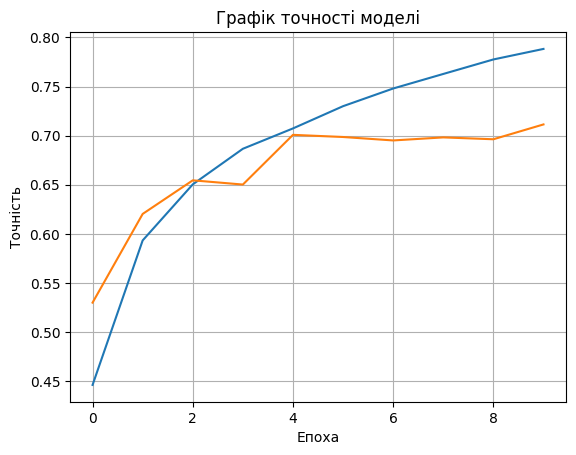

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Епоха")
plt.ylabel("Точність")
plt.title("Графік точності моделі")
plt.grid(True)
plt.show()

In [11]:
def load_and_prepare_image(img):
  image = Image.open(img).convert("RGB")
  image = image.resize((32, 32))
  image_array = np.array(image) / 255.0
  image_array = np.expand_dims(image_array, axis=0)

  return image_array

In [12]:
custom_image_path = 'Screenshot_1.png'  #@param {type:"string"}

In [13]:
import os

if os.path.exists(custom_image_path):
  try:
    prepared_img = load_and_prepare_image(custom_image_path)
    prediction = model.predict(prepared_img)
    # print(prediction)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Pred: {predicted_class} ({class_name[predicted_class]}) - on {confidence * 100:.2f}%")
  except Exception as e:
    print(f"Error: {e}")
else:
  print(f"Not found file {custom_image_path}")

Not found file Screenshot_1.png


---

In [14]:
from google.colab import files

print("Upload file (JPG or PNG):")
uploaded = files.upload()

Upload file (JPG or PNG):


Saving bus.jpg to bus.jpg
Saving tram.jpg to tram.jpg
Saving bicycle.jpeg to bicycle.jpeg
Saving motorcycle.jpg to motorcycle.jpg
Saving cat.jpg to cat.jpg
Saving dog.jpg to dog.jpg
Saving plane.jpg to plane.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
Pred: 9 (вантажівка) - on 71.54%


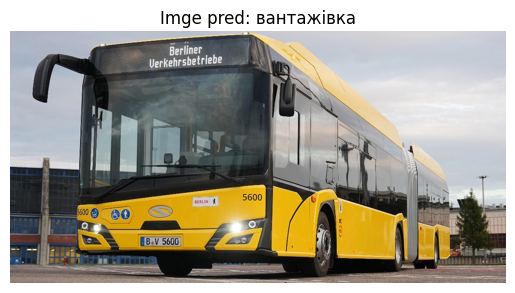

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Pred: 9 (вантажівка) - on 34.28%


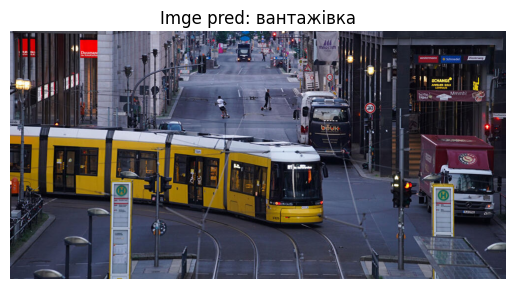

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Pred: 6 (жаба) - on 45.67%


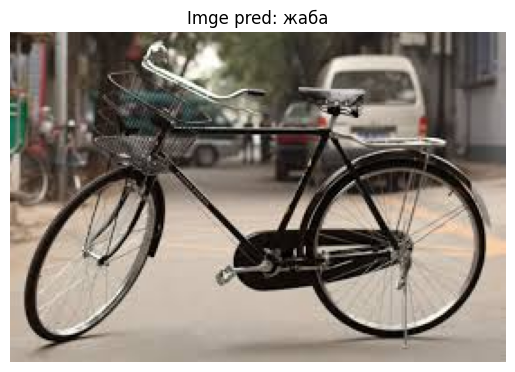

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Pred: 6 (жаба) - on 30.01%


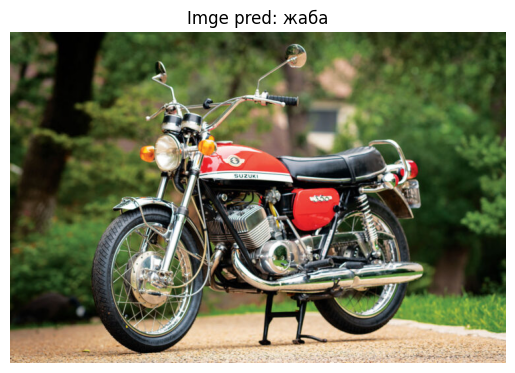

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Pred: 3 (кіт) - on 83.61%


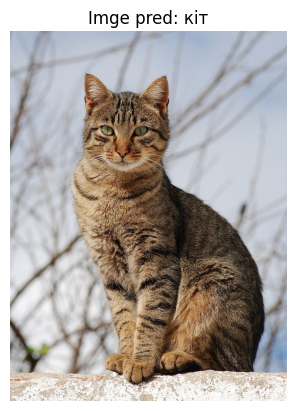

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Pred: 5 (собака) - on 96.71%


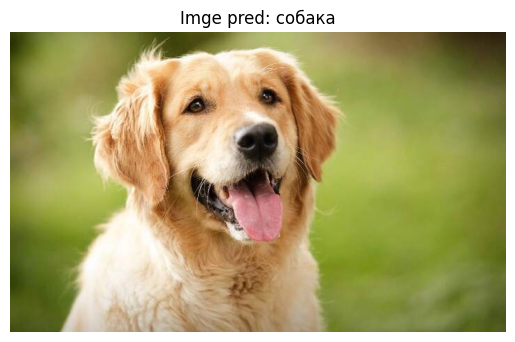

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Pred: 0 (літак) - on 94.24%


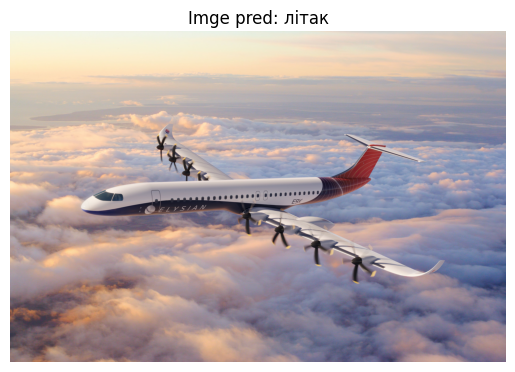

In [15]:
for f in uploaded.keys():
  img = f
  prepared_img = load_and_prepare_image(img)
  prediction = model.predict(prepared_img)
  # print(prediction)
  predicted_class = np.argmax(prediction)
  confidence = np.max(prediction)

  print(f"Pred: {predicted_class} ({class_name[predicted_class]}) - on {confidence * 100:.2f}%")

  img = Image.open(img)
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Imge pred: {class_name[predicted_class]}")
  plt.show()